# Dataset Characterization: TMDB

Initial characterization EDA for the TMDB dataset used in this
dissertation: the Full TMDB Movies Dataset 2024. Findings are logged to
`reports/eda_log.md` via `src/report.py`; figures are saved to
`reports/figures/00/` at 300dpi.

## Setup

### Imports & configuration

In [2]:
%matplotlib inline

import sys
import warnings
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config
from src.eda.helper import (
    empty_string_report,
    entity_embedding_dim,
    flag_non_english,
    high_corr_pairs,
    html_contamination_pct,
    iqr_outlier_count,
    list_field_summary,
    multihot_feasibility,
    near_duplicate_report,
    parse_list_field,
    text_field_report,
    token_length_stats,
    top_item_cooccurrence,
    zscore_outlier_count,
)
from src.eda.loaders import load_tmdb
from src.report import log_findings, savefig

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# This notebook's own figures subdirectory (src/report.py's per-notebook
# convention) -- bound into savefig once here so every savefig(fig, filename)
# call below lands in reports/figures/00/ without repeating figures_dir.
FIGURES_DIR = config.FIGURES_DIR / "00"
savefig = partial(savefig, figures_dir=FIGURES_DIR)

In [3]:
import sys
print(sys.executable)
import torch
print("torch imported fine")


c:\Users\knowu\miniconda3\envs\smart-tabular-embeddings\python.exe
torch imported fine


### Load datasets

In [4]:
tmdb_raw = load_tmdb()

print("TMDB raw shape:", tmdb_raw.shape)

TMDB raw shape: (1456829, 24)


## 1. Initial checks

### 1.1 Provenance & structural overview

#### Dataset provenance

In [5]:
display(Markdown(f"""
**Dataset provenance** (pulled from `src/eda/config.py`):

- TMDB download date: `{config.TMDB_DOWNLOAD_DATE}`
"""))


**Dataset provenance** (pulled from `src/eda/config.py`):

- TMDB download date: `2026-07-11`


#### Shape, dtypes & column list

In [6]:
tmdb_shape_raw = tmdb_raw.shape
print("TMDB shape:", tmdb_shape_raw)

TMDB shape: (1456829, 24)


In [7]:
tmdb_raw.dtypes

id                               Int64
title                           string
vote_average                   float64
vote_count                       Int64
status                        category
release_date            datetime64[us]
revenue                        float64
runtime                        float64
adult                             bool
backdrop_path                   string
budget                         float64
homepage                        string
imdb_id                         string
original_language             category
original_title                  string
overview                        string
popularity                     float64
poster_path                     string
tagline                         string
genres                          string
production_companies            string
production_countries            string
spoken_languages                string
keywords                        string
dtype: object

In [8]:
print("TMDB columns:")
print(list(tmdb_raw.columns))

TMDB columns:
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


#### Memory usage

In [9]:
tmdb_mem_mb = tmdb_raw.memory_usage(deep=True).sum() / 1e6
print(f"TMDB memory usage (deep): {tmdb_mem_mb:,.1f} MB")

CHUNKED_LOAD_THRESHOLD_MB = 2000
if tmdb_mem_mb > CHUNKED_LOAD_THRESHOLD_MB:
    print(f"FLAG: TMDB exceeds {CHUNKED_LOAD_THRESHOLD_MB} MB — consider chunked loading.")
else:
    print(f"TMDB is within comfortable in-memory limits ({tmdb_mem_mb:,.1f} MB).")

TMDB memory usage (deep): 734.2 MB
TMDB is within comfortable in-memory limits (734.2 MB).


#### Manual sample inspection

In [10]:
tmdb_raw.sample(10, random_state=config.RANDOM_SEED)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
231924,594409,"Wild: Life, Death and Love in a Wildlife Hospital",7.0,1,Released,2018-05-18,0.0,60.0,False,<NA>,...,פרא,"Patient-doctor relationships are never easy, b...",0.600,/q101zRez2PR3WoYwyutfdODmMa5.jpg,<NA>,Documentary,<NA>,Israel,Hebrew,<NA>
359111,389489,Chas & Dave Last Orders,6.0,1,Released,2012-10-26,0.0,60.0,False,<NA>,...,Chas & Dave Last Orders,Documentary which highlights cockney duo Chas ...,0.961,/ju8am65e7pxWapYjbDWwQ5ebkr7.jpg,<NA>,"Music, Documentary",<NA>,<NA>,<NA>,<NA>
324084,371913,Renoir: Reviled and Revered,5.0,1,Released,2016-12-10,0.0,90.0,False,/srOAs76LC1MJTdk2DNBpw8YQCW5.jpg,...,Renoir: Reviled and Revered,Pierre-Auguste Renoir is known and loved for h...,0.983,/9WlaPv0KMAD2Cb7AYgtYTL1b0IB.jpg,"Beloved Impressionist, influential master or s...",Documentary,Seventh Art Productions,United Kingdom,English,"painting, artist, painter, pierre-auguste renoir"
1343707,830964,Dřevo jde s hor,0.0,0,Released,1947-01-01,0.0,0.0,False,<NA>,...,Dřevo jde s hor,<NA>,0.600,<NA>,<NA>,Documentary,Československá výroba krátkých filmů Zlín,Czechoslovakia,No Language,<NA>
404882,1334385,分享大发计划2期必中,0.0,0,Released,NaT,0.0,0.0,False,<NA>,...,分享大发计划2期必中,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
377091,1171150,The 1820 Settlers,0.0,0,Released,1953-01-01,0.0,0.0,False,<NA>,...,Die 1820-Setlaars,Brief history of the British settlers who came...,0.600,<NA>,<NA>,<NA>,<NA>,<NA>,"Afrikaans, English",<NA>
202736,643751,The Pescara,3.5,2,Released,1912-09-30,0.0,4.0,False,<NA>,...,Il Pescara,"Recordings of the Pescara river in Italy, from...",0.600,/j3x2rjOvI5FVFLyRkptPUowPsRI.jpg,<NA>,Documentary,Società Anonima Ambrosio,Italy,<NA>,<NA>
1334685,808231,德云社张云雷杨九郎相声专场七夕济南站,0.0,0,Released,2018-09-10,0.0,0.0,False,/4d45QLoRll87cROAdLihir8PN4d.jpg,...,德云社张云雷杨九郎相声专场七夕济南站,<NA>,0.600,/2uQOXsqfklkxSIq5LTCez1HjOqY.jpg,<NA>,Comedy,YOUKU,China,Mandarin,<NA>
810618,1430864,Content,0.0,0,Released,2024-12-15,0.0,8.0,False,/7aeQ33Q9MLqBi42lnBC8u2X3kC7.jpg,...,Content,A content creator is forced by the algorithm t...,0.764,/yMmjFsufm35rWQfV2vtMgMyQPQd.jpg,The world is watching...,"Comedy, Thriller",Scatterbrain Pictures,<NA>,No Language,<NA>
946853,512054,So Long,0.0,0,Released,2017-03-15,0.0,72.0,False,/cqSc9XzNFD3XO9uWeNOBP62zBUl.jpg,...,So Long,Lesbian mumblecore drama So Long follows two w...,0.641,/dWU1pjKymKVv4FW7Ysb0u8v6Wot.jpg,<NA>,<NA>,<NA>,Australia,<NA>,<NA>


#### One Sample

In [11]:
with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    print(tmdb_raw.loc[tmdb_raw['id'] == 24428])

      id         title  vote_average  vote_count    status release_date  \
4  24428  The Avengers          7.71       29166  Released   2012-04-25   

        revenue  runtime  adult                     backdrop_path  \
4  1.518816e+09    143.0  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg   

        budget                                    homepage    imdb_id  \
4  220000000.0  https://www.marvel.com/movies/the-avengers  tt0848228   

  original_language original_title  \
4                en   The Avengers   

                                                                                                                                                                                                                                                                                                    overview  \
4  When an unexpected enemy emerges and threatens global safety and security, Nick Fury, director of the international peacekeeping agency known as S.H.I.E.L.D., finds himself in nee

#### Missingness

In [11]:
tmdb_missing = pd.DataFrame(
    {
        "n_missing": tmdb_raw.isnull().sum(),
        "pct_missing": tmdb_raw.isnull().mean() * 100,
    }
).sort_values("pct_missing", ascending=False)
tmdb_missing

,n_missing,pct_missing
homepage,1307503,89.749929
tagline,1253340,86.032060
keywords,1100079,75.511882
backdrop_path,1098497,75.403290
production_companies,841071,57.732994
imdb_id,780621,53.583571
production_countries,711467,48.836686
spoken_languages,684011,46.952044
genres,646281,44.362173
poster_path,524527,36.004706


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_missingness_matrix.png


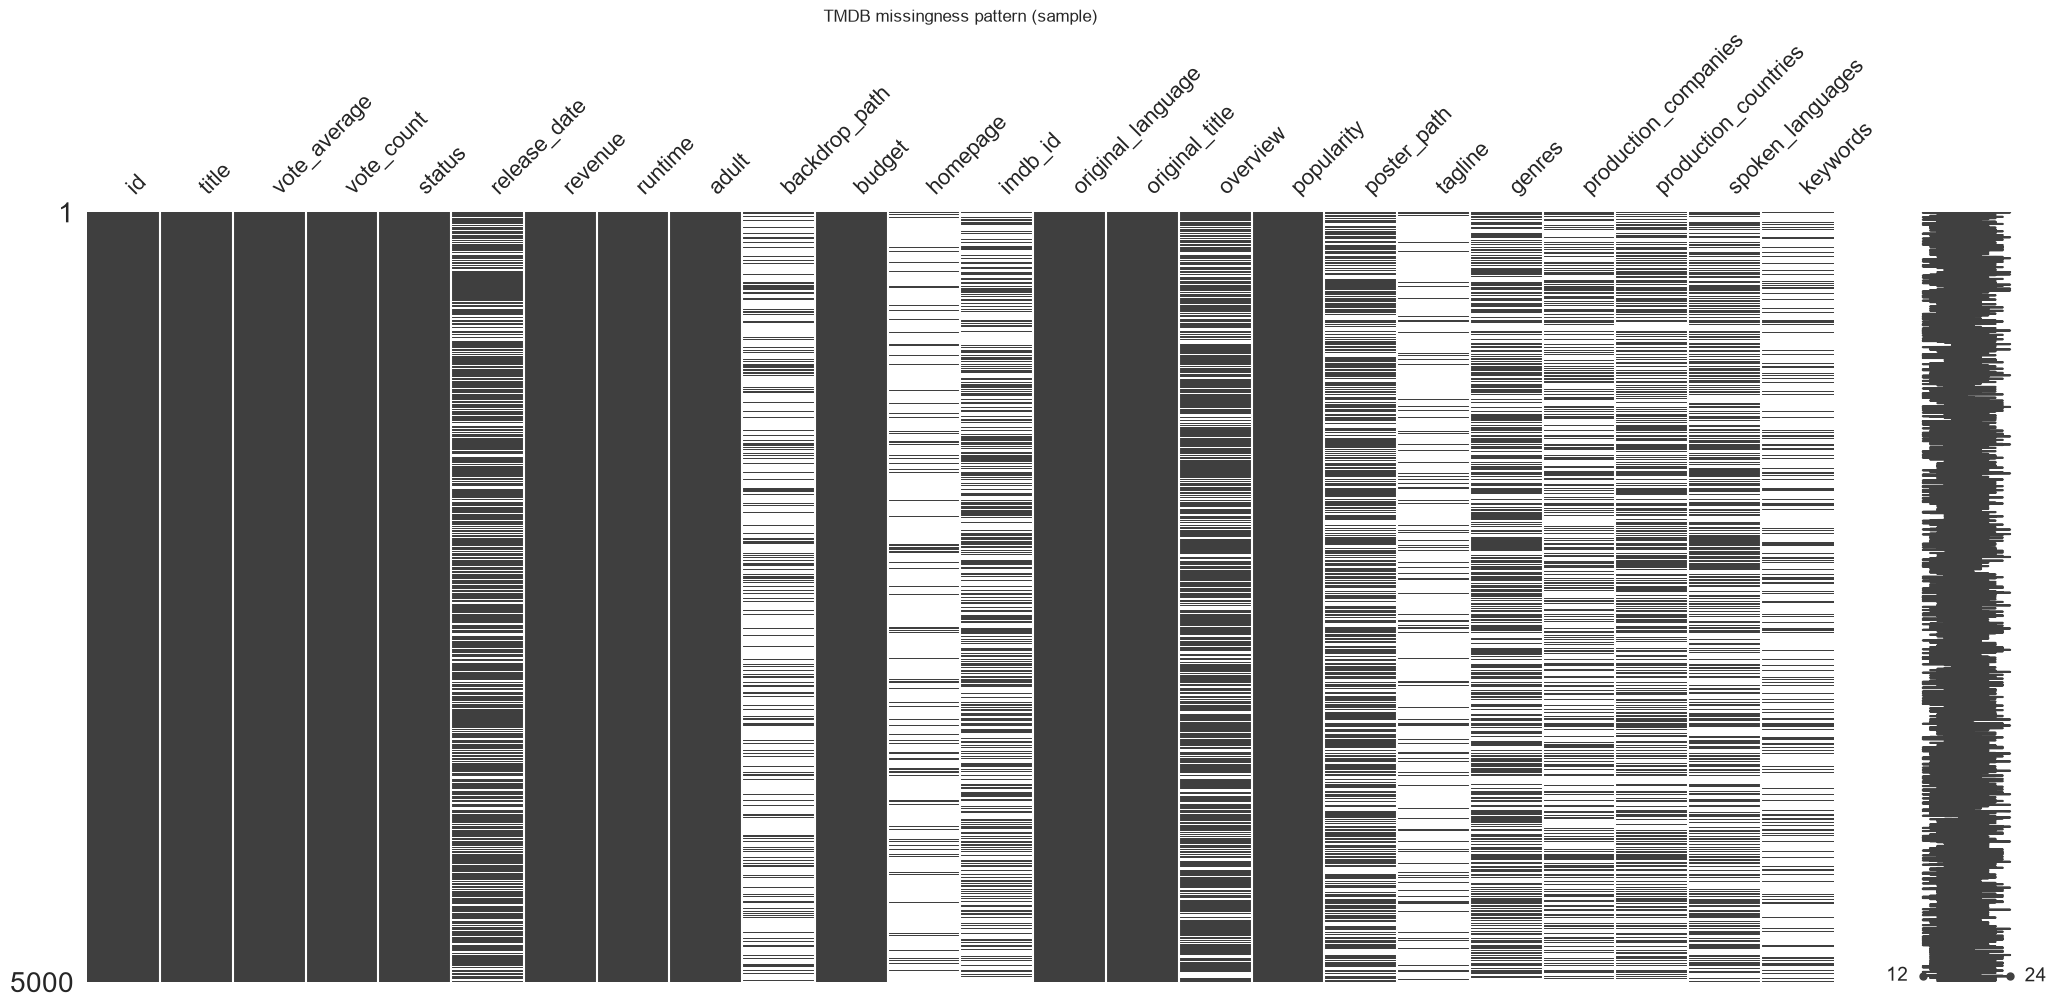

In [12]:
msno.matrix(tmdb_raw.sample(min(len(tmdb_raw), 5000), random_state=config.RANDOM_SEED))
plt.title("TMDB missingness pattern (sample)")
fig = plt.gcf()
savefig(fig, "00_tmdb_missingness_matrix.png")
plt.show()

#### Duplicate `id` / `imdb_id` check

In [13]:
tmdb_dupe_ids = int(tmdb_raw["id"].duplicated().sum())
print(f"TMDB duplicate ids: {tmdb_dupe_ids}")

TMDB duplicate ids: 1296


In [14]:
# Do duplicate-id rows actually agree on core identity fields, or do they
# genuinely conflict (which would mean the same id was reused across two
# different movies, not just re-entered with more fields filled in)?
key_cols = ["imdb_id", "title", "release_date", "budget", "revenue", "vote_average"]
tmdb_dupe_id_rows = tmdb_raw[tmdb_raw["id"].duplicated(keep=False)]
n_distinct_non_null = tmdb_dupe_id_rows.groupby("id")[key_cols].agg(lambda s: s.dropna().nunique())
conflicting_ids = n_distinct_non_null[(n_distinct_non_null > 1).any(axis=1)]
n_dupe_id_groups = tmdb_dupe_id_rows["id"].nunique()
print(f"{len(conflicting_ids)} of {n_dupe_id_groups} duplicate-id groups "
      f"have conflicting (not just missing-vs-present) values in {key_cols}")

tmdb_dupe_id_rows[tmdb_dupe_id_rows["id"].isin(conflicting_ids.index)][["id"] + key_cols].sort_values("id")

184 of 949 duplicate-id groups have conflicting (not just missing-vs-present) values in ['imdb_id', 'title', 'release_date', 'budget', 'revenue', 'vote_average']


,id,imdb_id,title,release_date,budget,revenue,vote_average
591174,1192941,<NA>,एकदा येऊन तर बघा,NaT,0.0,0.0,0.0
591203,1192941,<NA>,Ekda Yeun Tar Bagha,2023-11-24,0.0,0.0,0.0
591228,1192941,<NA>,Ekda Yeun Tar Bagha,2023-11-24,0.0,0.0,0.0
591220,1192941,<NA>,एकदा येऊन तर बघा,NaT,0.0,0.0,0.0
591170,1192944,<NA>,Julekonsert med Odd Nordstoga,NaT,0.0,0.0,0.0
...,...,...,...,...,...,...,...
745080,1725195,<NA>,JUDGMENT OF THE BOURGEOIS,2026-07-04,1.0,1.0,0.0
725796,1725735,<NA>,Birdcage,NaT,0.0,0.0,0.0
328058,1725735,<NA>,Birdcage,2026-05-06,0.0,0.0,6.0
365765,1729173,<NA>,Dalajlama - Oceán moudrosti,NaT,0.0,0.0,0.0


#### `vote_average` / `vote_count` zero combinations

In [15]:
vote_avg_zero = tmdb_raw["vote_average"] == 0
vote_count_zero = tmdb_raw["vote_count"] == 0

n_both_zero = int((vote_avg_zero & vote_count_zero).sum())
n_avg_nonzero_count_zero = int((~vote_avg_zero & vote_count_zero).sum())
n_avg_zero_count_nonzero = int((vote_avg_zero & ~vote_count_zero).sum())
n_both_nonzero = int((~vote_avg_zero & ~vote_count_zero).sum())

print(f"vote_average==0 and vote_count==0:    {n_both_zero}")
print(f"vote_average!=0 and vote_count==0:    {n_avg_nonzero_count_zero}")
print(f"vote_average==0 and vote_count!=0:    {n_avg_zero_count_nonzero}")
print(f"vote_average!=0 and vote_count!=0:    {n_both_nonzero}")
print(f"total:                                {len(tmdb_raw)}")

# DECISION: vote_count==0 means zero votes were cast, so vote_average cannot
# be anything but 0 in that case -- an average requires at least one value
# to average. The 582 rows above with vote_count==0 but vote_average!=0 are
# therefore logically impossible, not just noisy: corrupted/erroneous records.
# TODO: remove (or recode vote_average to NaN) for these 582 rows as part of
# Section 1.2's cleaning, once the target-variable decision (deferred in
# Section 1.4) is finalized.

vote_average==0 and vote_count==0:    1096448
vote_average!=0 and vote_count==0:    582
vote_average==0 and vote_count!=0:    859
vote_average!=0 and vote_count!=0:    358940
total:                                1456829


In [16]:
# imdb_id is an external reference, not TMDB's own primary key, so unlike
# id above it can legitimately repeat if the same real movie was entered
# more than once in TMDB — a stronger duplicate-record signal than two rows
# merely sharing a title. "tt0000000" is IMDb's own placeholder for "no ID
# assigned" (not a real shared ID), so it's excluded here to avoid treating
# unrelated movies with an unknown imdb_id as false-positive duplicates.
tmdb_imdb_id_present = tmdb_raw["imdb_id"].dropna()
tmdb_imdb_id_present = tmdb_imdb_id_present[tmdb_imdb_id_present != "tt0000000"]
tmdb_dupe_imdb_id_mask = tmdb_imdb_id_present.duplicated(keep=False)
tmdb_dupe_imdb_ids = int(tmdb_imdb_id_present.duplicated().sum())
print(f"TMDB duplicate imdb_ids (excluding missing/placeholder values): {tmdb_dupe_imdb_ids} "
      f"out of {len(tmdb_imdb_id_present)} non-null, non-placeholder values")

tmdb_dupe_imdb_id_rows = tmdb_raw.loc[
    tmdb_imdb_id_present[tmdb_dupe_imdb_id_mask].index,
    ["id", "imdb_id", "title", "release_date"],
].sort_values("imdb_id")
tmdb_dupe_imdb_id_rows.head(20)

TMDB duplicate imdb_ids (excluding missing/placeholder values): 4518 out of 676206 non-null, non-placeholder values


,id,imdb_id,title,release_date
566921,1185484,tt0002844,Fantômas: In the Shadow of the Guillotine,1913-05-09
742879,1680343,tt0002844,Fantômas I: À l'ombre de la guillotine,1913-03-12
387557,1317649,tt0003037,Juve contre Fantômas,NaT
566923,1185482,tt0003037,Fantômas: The Man in Black,1914-09-12
751391,1628660,tt0003037,Fantômas: Juve versus Fantômas,1913-09-12
792708,1412321,tt0003037,Juve contre Fantômas,1913-09-12
343908,1663537,tt0003165,The Murderous Corpse,1913-05-09
387563,1317653,tt0003165,Fantômas - Le Mort qui tue,NaT
566949,1185457,tt0003165,Fantômas: The Dead Man Who Killed,1913-11-28
522259,1217400,tt0003930,Fantômas contre Fantômas,1914-01-05


### 1.2 TMDB cleaning: status filter, deduplication & zero-coding

In [17]:
tmdb = tmdb_raw.copy()

#### Recode `budget`/`revenue` zeros as NaN

In [18]:
zero_recode_report = {}
for col in ["budget", "revenue"]:
    pct_zero = float((tmdb[col] == 0).mean() * 100)
    zero_recode_report[col] = pct_zero
    tmdb[col] = tmdb[col].replace(0, np.nan)
    print(f"{col}: {pct_zero:.1f}% of rows were 0 -> recoded as NaN")

budget: 94.2% of rows were 0 -> recoded as NaN
revenue: 98.3% of rows were 0 -> recoded as NaN


#### Recode `runtime` zeros as NaN

In [19]:
pct_zero_runtime = float((tmdb["runtime"] == 0).mean() * 100)
tmdb["runtime"] = tmdb["runtime"].replace(0, np.nan)
print(f"runtime: {pct_zero_runtime:.1f}% of rows were 0 -> recoded as NaN")

runtime: 31.3% of rows were 0 -> recoded as NaN


#### Recode placeholder `imdb_id` values as NaN

In [20]:
tmdb_imdb_id_placeholder_pct = float((tmdb["imdb_id"] == "tt0000000").mean() * 100)
tmdb["imdb_id"] = tmdb["imdb_id"].replace("tt0000000", np.nan)
print(f"imdb_id: {tmdb_imdb_id_placeholder_pct:.3f}% of rows were the placeholder "
      f"'tt0000000' -> recoded as NaN")

imdb_id: 0.000% of rows were the placeholder 'tt0000000' -> recoded as NaN


#### Recode negative `runtime`/`revenue` values as NaN

In [21]:
tmdb_neg_recode_report = {}
for col in ["runtime", "revenue"]:
    pct_negative = float((tmdb[col] < 0).mean() * 100)
    tmdb_neg_recode_report[col] = pct_negative
    tmdb[col] = tmdb[col].where(tmdb[col] >= 0, np.nan)
    print(f"{col}: {pct_negative:.4f}% of rows were negative -> recoded as NaN")

runtime: 0.0001% of rows were negative -> recoded as NaN
revenue: 0.0001% of rows were negative -> recoded as NaN


#### Missing values after recode

In [22]:
tmdb_missing_recode = pd.DataFrame(
    {
        "n_missing": tmdb.isnull().sum(),
        "pct_missing": tmdb.isnull().mean() * 100,
    }
).sort_values("pct_missing", ascending=False)
tmdb_missing_recode

,n_missing,pct_missing
revenue,1431997,98.295476
budget,1372022,94.178658
homepage,1307503,89.749929
tagline,1253340,86.032060
keywords,1100079,75.511882
backdrop_path,1098497,75.403290
production_companies,841071,57.732994
imdb_id,780623,53.583708
production_countries,711467,48.836686
spoken_languages,684011,46.952044


#### Filter to `status == 'Released'`

In [23]:
status_counts = tmdb_raw["status"].value_counts(dropna=False)
status_pct = (status_counts / len(tmdb_raw) * 100).round(2)
pd.DataFrame({"count": status_counts, "pct": status_pct})

,count,pct
status,,
Released,1402648,96.28
In Production,24534,1.68
Post Production,16237,1.11
Planned,12179,0.84
Rumored,855,0.06
Canceled,376,0.03


In [24]:
# Verify the claim behind the filter across every column, not just the
# handful expected to be post-release-only.
released_mask = tmdb_raw["status"] == "Released"
missingness_by_status = pd.DataFrame({
    "% missing (Released)": tmdb_raw.loc[released_mask].isnull().mean() * 100,
    "% missing (non-Released)": tmdb_raw.loc[~released_mask].isnull().mean() * 100,
})
missingness_by_status["gap"] = missingness_by_status["% missing (non-Released)"] - missingness_by_status["% missing (Released)"]
missingness_by_status.round(2).sort_values("gap", ascending=False)

,% missing (Released),% missing (non-Released),gap
release_date,21.58,57.09,35.51
poster_path,35.19,57.12,21.93
imdb_id,52.87,72.17,19.31
backdrop_path,75.13,82.41,7.27
overview,23.09,23.86,0.77
homepage,89.74,90.01,0.27
original_title,0.00,0.01,0.01
title,0.00,0.01,0.01
runtime,0.00,0.00,0.00
revenue,0.00,0.00,0.00


In [25]:
shape_before_status_filter = tmdb.shape
tmdb = tmdb[tmdb["status"] == "Released"].copy()
tmdb_shape_after_status_filter = tmdb.shape
print(f"TMDB shape before status filter: {shape_before_status_filter}")
print(f"TMDB shape after status filter: {tmdb_shape_after_status_filter}")

TMDB shape before status filter: (1456829, 24)
TMDB shape after status filter: (1402648, 24)


#### Drop duplicate `id` rows (keep most complete)

In [26]:
# DECISION POINT: "most complete" is currently just the row with the
# fewest total NaNs across ALL columns, treating every column as equally
# important. A row missing 2 minor fields (e.g. homepage, poster_path)
# scores the same as one missing 2 consequential ones (e.g. budget,
# revenue). Ties are broken arbitrarily by original row order (stable sort).
# TODO: revisit with column-weighted completeness (e.g. weight budget/
# revenue/overview higher than homepage/poster_path) if this heuristic
# turns out to pick the wrong row in practice.
tmdb_shape_before_dedup = tmdb.shape
tmdb = (
    tmdb.assign(_null_count=tmdb.isnull().sum(axis=1))
    .sort_values("_null_count")
    .drop_duplicates(subset="id", keep="first")
    .drop(columns="_null_count")
    .sort_index()
)
tmdb_shape_after_dedup = tmdb.shape
tmdb_n_dupe_ids_dropped = tmdb_shape_before_dedup[0] - tmdb_shape_after_dedup[0]
print(f"TMDB: dropped {tmdb_n_dupe_ids_dropped} duplicate-id rows (kept the most complete row per id)")
print(f"Shape before dedup: {tmdb_shape_before_dedup}, after: {tmdb_shape_after_dedup}")

TMDB: dropped 1150 duplicate-id rows (kept the most complete row per id)
Shape before dedup: (1402648, 24), after: (1401498, 24)


### 1.3 Candidate outcome variable distributions

#### TMDB `vote_average` distribution

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_vote_average_hist.png


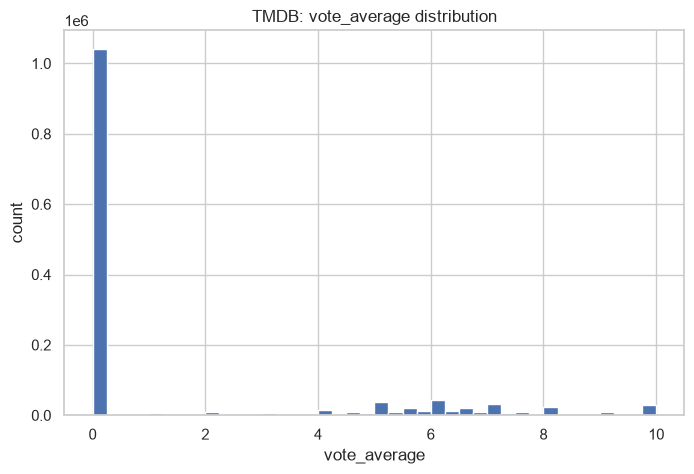

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb["vote_average"].dropna().hist(bins=40, ax=ax)
ax.set_title("TMDB: vote_average distribution")
ax.set_xlabel("vote_average")
ax.set_ylabel("count")
savefig(fig, "00_tmdb_vote_average_hist.png")
plt.show()

In [28]:
for threshold in [1, 5, 10, 20, 50]:
    print(f"vote_count >= {threshold}: {(tmdb['vote_count'] >= threshold).sum():,} rows")

vote_count >= 1: 359,713 rows
vote_count >= 5: 125,866 rows
vote_count >= 10: 78,852 rows
vote_count >= 20: 50,430 rows
vote_count >= 50: 27,981 rows


In [29]:
vote_avg_zero = tmdb_raw["vote_average"] == 0
vote_count_zero = tmdb_raw["vote_count"] == 0

n_both_zero = int((vote_avg_zero & vote_count_zero).sum())
n_avg_nonzero_count_zero = int((~vote_avg_zero & vote_count_zero).sum())
n_avg_zero_count_nonzero = int((vote_avg_zero & ~vote_count_zero).sum())
n_both_nonzero = int((~vote_avg_zero & ~vote_count_zero).sum())

print(f"vote_average==0 and vote_count==0:    {n_both_zero}")
print(f"vote_average!=0 and vote_count==0:    {n_avg_nonzero_count_zero}")
print(f"vote_average==0 and vote_count!=0:    {n_avg_zero_count_nonzero}")
print(f"vote_average!=0 and vote_count!=0:    {n_both_nonzero}")
print(f"total:                                {len(tmdb_raw)}")

# DECISION: vote_count==0 means zero votes were cast, so vote_average cannot
# be anything but 0 in that case -- an average requires at least one value
# to average. The 582 rows above with vote_count==0 but vote_average!=0 are
# therefore logically impossible, not just noisy: corrupted/erroneous records.
# TODO: remove (or recode vote_average to NaN) for these 582 rows as part of
# Section 1.2's cleaning, once the target-variable decision (deferred in
# Section 1.4) is finalized.

vote_average==0 and vote_count==0:    1096448
vote_average!=0 and vote_count==0:    582
vote_average==0 and vote_count!=0:    859
vote_average!=0 and vote_count!=0:    358940
total:                                1456829


## 2. Numerical features (Section 2a)

In [30]:
TMDB_NUM_COLS = [c for c in ["vote_average", "vote_count", "revenue", "runtime", "budget", "popularity"] if c in tmdb.columns]
TMDB_TARGET = "vote_average"

print("TMDB numeric columns:", TMDB_NUM_COLS)

TMDB numeric columns: ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']


### Descriptive stats & outliers

#### `describe()` and physically impossible values

In [31]:
tmdb[TMDB_NUM_COLS].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.401498e+06,1401498.0,2.445500e+04,981326.000000,7.863300e+04,1.401498e+06
mean,1.580909e+00,15.311243,3.567669e+07,63.597059,4.091961e+06,1.003764e+00
std,2.876485e+00,286.934071,1.433504e+08,64.012300,2.064306e+07,6.845086e+00
min,0.000000e+00,0.0,1.000000e+00,1.000000,1.000000e+00,0.000000e+00
25%,0.000000e+00,0.0,1.150000e+03,14.000000,1.550000e+02,2.140000e-02
50%,0.000000e+00,0.0,7.800000e+05,61.000000,3.000000e+03,6.000000e-01
75%,2.000000e+00,1.0,1.327878e+07,94.000000,1.500000e+05,6.800000e-01
max,1.000000e+01,34495.0,5.000000e+09,14400.000000,1.000000e+09,2.994357e+03


In [32]:
impossible_flags = []
if "runtime" in tmdb.columns:
    impossible_flags.append(("TMDB", "runtime == 0", int((tmdb["runtime"] == 0).sum())))
    impossible_flags.append(("TMDB", "runtime < 0", int((tmdb["runtime"] < 0).sum())))
if "revenue" in tmdb.columns:
    impossible_flags.append(("TMDB", "revenue < 0", int((tmdb["revenue"] < 0).sum())))
if "budget" in tmdb.columns:
    impossible_flags.append(("TMDB", "budget < 0", int((tmdb["budget"] < 0).sum())))

pd.DataFrame(impossible_flags, columns=["dataset", "check", "n_rows"])

,dataset,check,n_rows
0,TMDB,runtime == 0,0
1,TMDB,runtime < 0,0
2,TMDB,revenue < 0,0
3,TMDB,budget < 0,0


In [33]:
tmdb_neg_recode_report = {}
for col in ["runtime", "revenue"]:
    pct_negative = float((tmdb[col] < 0).mean() * 100)
    tmdb_neg_recode_report[col] = pct_negative
    tmdb[col] = tmdb[col].where(tmdb[col] >= 0, np.nan)
    print(f"{col}: {pct_negative:.4f}% of rows were negative -> recoded as NaN")

runtime: 0.0000% of rows were negative -> recoded as NaN
revenue: 0.0000% of rows were negative -> recoded as NaN


#### Outlier detection: IQR (1.5x) vs z-score (|z|>3)

In [34]:
tmdb_outlier_summary = pd.DataFrame({
    "column": TMDB_NUM_COLS,
    "iqr_outliers": [iqr_outlier_count(tmdb[c]) for c in TMDB_NUM_COLS],
    "zscore_outliers": [zscore_outlier_count(tmdb[c]) for c in TMDB_NUM_COLS],
})
tmdb_outlier_summary["disagreement"] = (
    tmdb_outlier_summary["iqr_outliers"] - tmdb_outlier_summary["zscore_outliers"]
).abs()
tmdb_outlier_summary

,column,iqr_outliers,zscore_outliers,disagreement
0,vote_average,256848,0,256848
1,vote_count,175493,4329,171164
2,revenue,4064,379,3685
3,runtime,12278,6452,5826
4,budget,17152,1193,15959
5,popularity,117256,4224,113032


IQR and z-score disagree substantially wherever a column is skewed rather
than roughly normal: IQR is robust to skew and flags points relative to the
central 50%, while z-score assumes a symmetric distribution and under- or
over-counts outliers accordingly. Treat the two counts as complementary,
not interchangeable.

#### Histogram

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_histograms.png


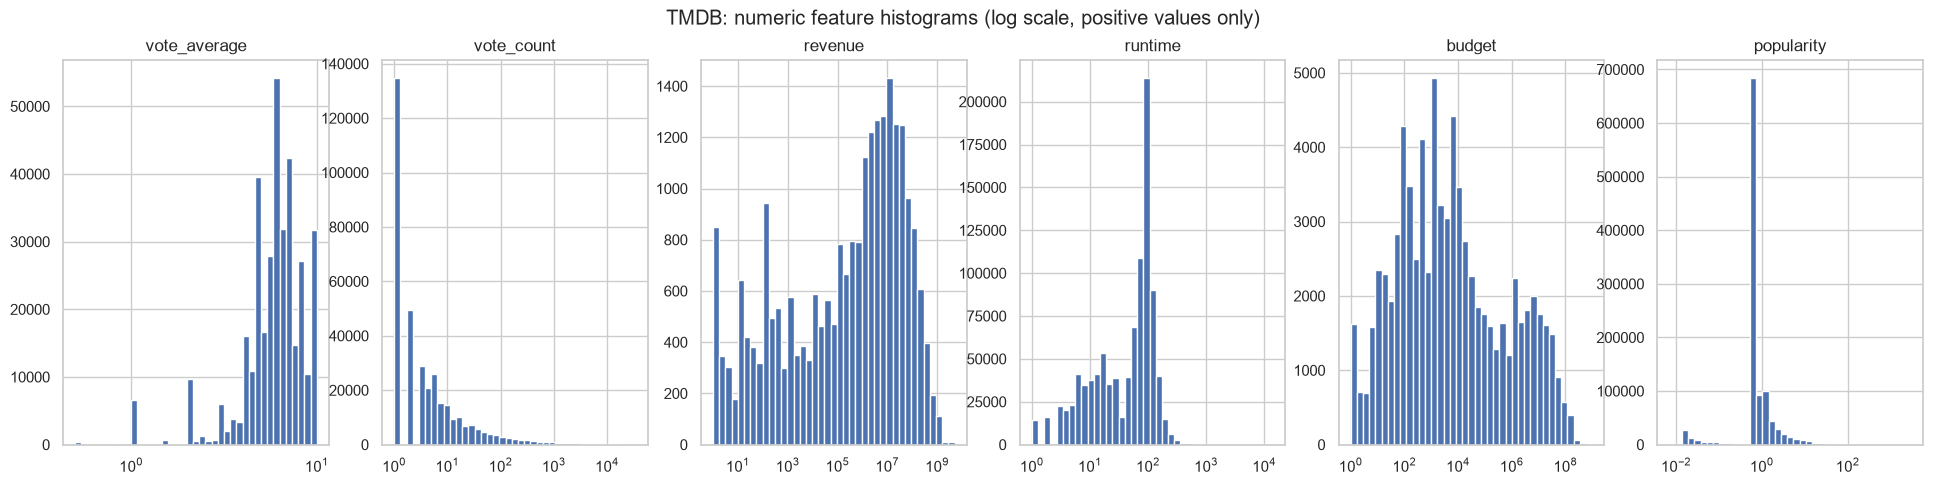

In [35]:
fig, axes = plt.subplots(1, len(TMDB_NUM_COLS), figsize=(4 * len(TMDB_NUM_COLS), 5))
for ax, col in zip(np.atleast_1d(axes), TMDB_NUM_COLS):
    values = tmdb[col].dropna()
    values = values[values > 0]
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 40)
    ax.hist(values, bins=bins)
    ax.set_xscale("log")
    ax.set_title(col)
fig.suptitle("TMDB: numeric feature histograms (log scale, positive values only)")
savefig(fig, "00_tmdb_histograms.png")
plt.show()

#### Boxplots

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_boxplots.png


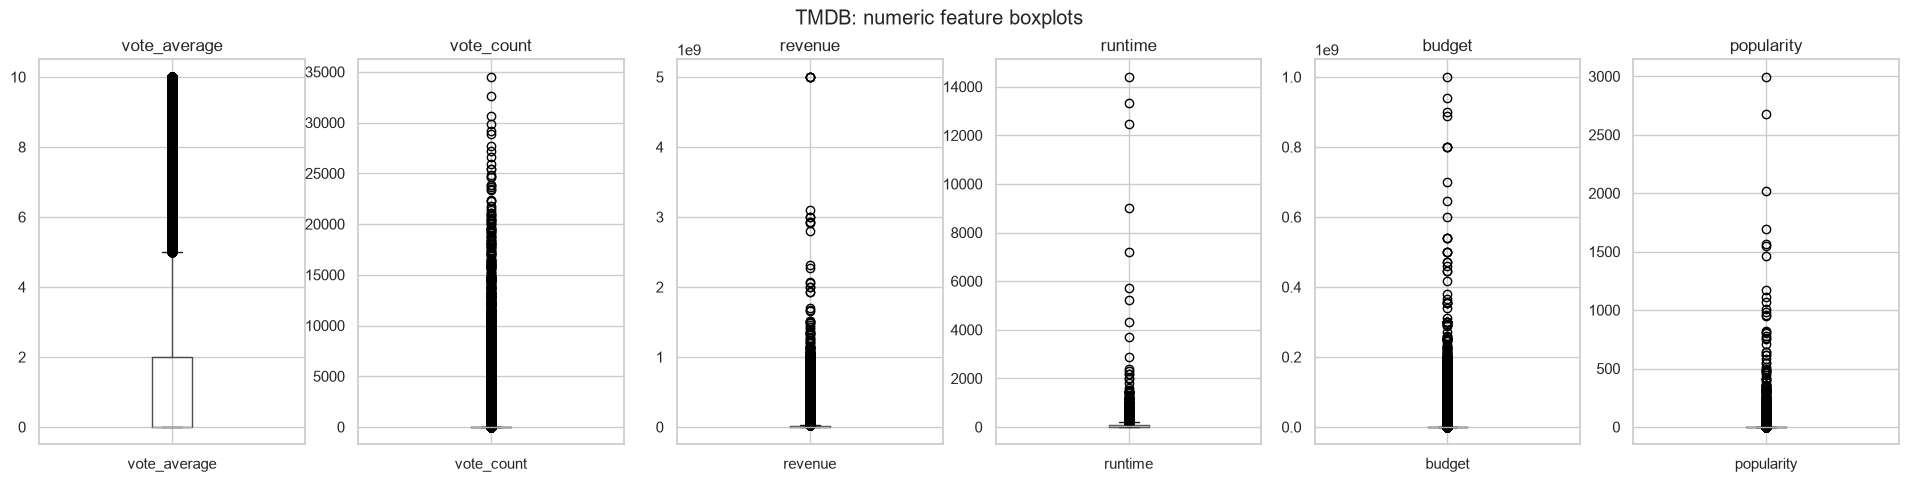

In [36]:
fig, axes = plt.subplots(1, len(TMDB_NUM_COLS), figsize=(4 * len(TMDB_NUM_COLS), 5))
for ax, col in zip(np.atleast_1d(axes), TMDB_NUM_COLS):
    tmdb.boxplot(column=col, ax=ax)
    ax.set_title(col)
fig.suptitle("TMDB: numeric feature boxplots")
savefig(fig, "00_tmdb_boxplots.png")
plt.show()

### Skewness & transforms

#### Skewness

In [37]:
# DECISION POINT: skewness flagging threshold — currently |skew| > 2, the
# more lenient end of common convention (some sources treat |skew| > 1 as
# already "highly skewed"; > 2 follows George & Mallery's more relaxed
# guideline). Columns with skew ~1.0-2.0 won't be flagged at this setting.
# TODO: revisit this threshold (e.g. try 1.0) if downstream modeling shows
# unflagged columns in that 1-2 range are still causing problems.
tmdb_skew = tmdb[TMDB_NUM_COLS].skew().sort_values(ascending=False)
tmdb_skew_flagged = tmdb_skew[tmdb_skew.abs() > 2]
print("TMDB skewness:")
print(tmdb_skew)
print()
print("Flagged (|skew| > 2) as log-transform / quantile-binning candidates:")
print(tmdb_skew_flagged)

TMDB skewness:
popularity      191.685827
vote_count        45.49905
runtime          36.611654
budget           15.010036
revenue          13.287714
vote_average      1.497591
dtype: Float64

Flagged (|skew| > 2) as log-transform / quantile-binning candidates:
popularity    191.685827
vote_count      45.49905
runtime        36.611654
budget         15.010036
revenue        13.287714
dtype: Float64


### Correlations

#### Correlation matrix & multicollinearity flags

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_correlation_heatmap.png


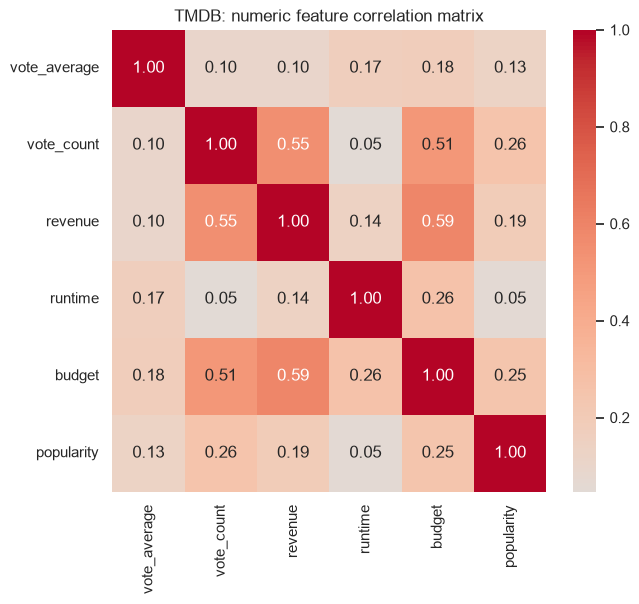

In [38]:
tmdb_corr = tmdb[TMDB_NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(tmdb_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("TMDB: numeric feature correlation matrix")
savefig(fig, "00_tmdb_correlation_heatmap.png")
plt.show()

In [39]:
tmdb_high_corr_pairs = high_corr_pairs(tmdb_corr, threshold=0.75)
print("TMDB pairs with |r| > 0.75 (multicollinearity risk):")
tmdb_high_corr_pairs

TMDB pairs with |r| > 0.75 (multicollinearity risk):


,feature_1,feature_2,correlation


In [40]:
tmdb_target_corr = tmdb_corr[TMDB_TARGET].drop(TMDB_TARGET).abs().sort_values(ascending=False)
print(f"TMDB numeric features ranked by |r| with {TMDB_TARGET}:")
tmdb_target_corr

TMDB numeric features ranked by |r| with vote_average:


budget        0.179070
runtime       0.168988
popularity    0.128031
revenue       0.099065
vote_count    0.097372
Name: vote_average, dtype: float64

## 3. Categorical features (Section 2b)

In [41]:
# "status" is excluded here: Section 1 already filtered tmdb to
# status == 'Released', so it is now a constant column post-cleaning and
# uninformative for cardinality/long-tail analysis.
TMDB_CAT_COLS = [c for c in ["original_language"] if c in tmdb.columns]
print("TMDB categorical columns:", TMDB_CAT_COLS)

TMDB categorical columns: ['original_language']


### Cardinality & distributions

#### Cardinality

In [42]:
cardinality_table = pd.DataFrame({
    "dataset": "TMDB", "column": TMDB_CAT_COLS,
    "cardinality": [tmdb[c].nunique() for c in TMDB_CAT_COLS],
})
cardinality_table

,dataset,column,cardinality
0,TMDB,original_language,179


#### Value counts & long-tail categories

In [43]:
for c in TMDB_CAT_COLS:
    vc = tmdb[c].value_counts(normalize=True)
    print(f"--- TMDB: {c} (top 5) ---")
    print(vc.head(5))
    long_tail = vc[vc < 0.01]
    print(f"{len(long_tail)} long-tail categories (<1% share each) — candidates for binning into 'Other'")
    print()

--- TMDB: original_language (top 5) ---
original_language
en    0.549217
fr    0.057673
es    0.051244
ja    0.046580
de    0.045183
Name: proportion, dtype: float64
169 long-tail categories (<1% share each) — candidates for binning into 'Other'



#### Long-tail visualization

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_original_language_long_tail.png


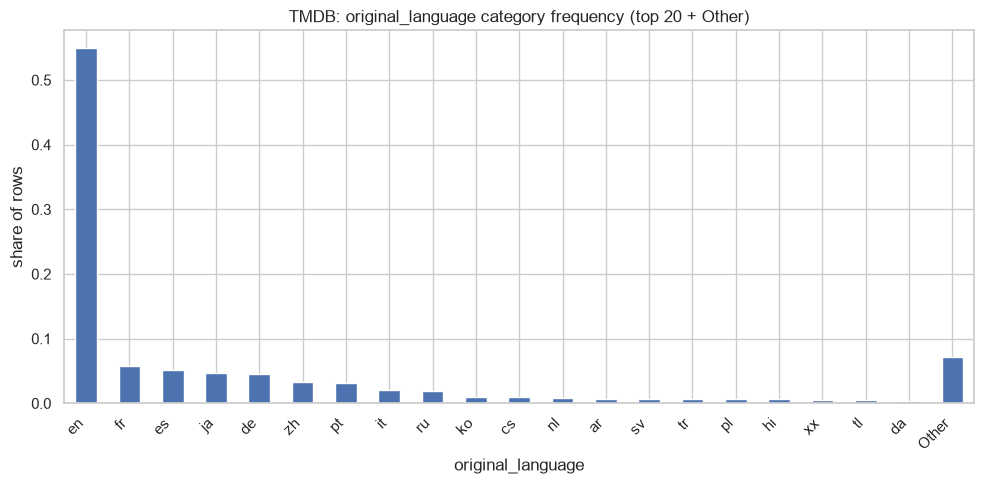

In [44]:
CAT_COLS_TO_PLOT = {
    "TMDB": TMDB_CAT_COLS,
}

for dataset_name, df_, cols in [("TMDB", tmdb, CAT_COLS_TO_PLOT["TMDB"])]:
    for c in cols:
        vc = df_[c].value_counts(normalize=True)
        top20 = vc.head(20)
        other_share = vc.iloc[20:].sum()
        plot_data = top20.copy()
        if other_share > 0:
            plot_data["Other"] = other_share

        fig, ax = plt.subplots(figsize=(10, 5))
        plot_data.plot(kind="bar", ax=ax)
        ax.set_title(f"{dataset_name}: {c} category frequency (top 20 + Other)")
        ax.set_ylabel("share of rows")
        ax.set_xlabel(c)
        plt.xticks(rotation=45, ha="right")
        fig.tight_layout()
        savefig(fig, f"00_{dataset_name.lower()}_{c}_long_tail.png")
        plt.show()

### Empty-string missingness (distinct from Section 1's `isnull()` check)

In [45]:
empty_string_report(tmdb, TMDB_CAT_COLS)

,column,null_count,empty_string_count
0,original_language,0,0


### Binary-looking field audit

### Entity-embedding dimension heuristic

Suggested embedding dimension per categorical field, using
`min(50, (cardinality // 2) + 1)` (Guo & Berkhahn, 2016, *Entity Embeddings
of Categorical Variables*).

In [46]:
def embedding_dim_table(df, cols, dataset_name):
    table = pd.DataFrame({"dataset": dataset_name, "column": cols})
    table["cardinality"] = [df[c].nunique() for c in cols]
    table["suggested_embedding_dim"] = table["cardinality"].apply(entity_embedding_dim)
    return table

embedding_dim_summary = embedding_dim_table(tmdb, TMDB_CAT_COLS, "TMDB")
embedding_dim_summary

,dataset,column,cardinality,suggested_embedding_dim
0,TMDB,original_language,179,90


### Fairness-relevant grouping

In [47]:
FAIRNESS_MIN_GROUP_SIZE = 100

tmdb_lang_counts = tmdb["original_language"].value_counts()
tmdb_small_lang_groups = tmdb_lang_counts[tmdb_lang_counts < FAIRNESS_MIN_GROUP_SIZE]
print(f"TMDB original_language: {len(tmdb_small_lang_groups)} / {len(tmdb_lang_counts)} groups "
      f"have < {FAIRNESS_MIN_GROUP_SIZE} samples — unreliable for later fairness metrics:")
tmdb_small_lang_groups

TMDB original_language: 98 / 179 groups have < 100 samples — unreliable for later fairness metrics:


original_language
bo    96
yi    93
ab    85
se    79
ht    72
      ..
ii     1
rn     1
kg     1
kj     1
kv     1
Name: count, Length: 98, dtype: int64

## 4. Free-text string features (Section 2c)

Covers TMDB `overview` — the long free-text field in the dataset.

### Free-text field audit

Scans every string-typed column (not just `overview`/`tagline`) for its uniqueness ratio (`nunique / non-null count`), to check whether any other fields deserve the same free-text treatment. List-valued raw string columns (`genres`, `keywords`, `production_companies`, `production_countries`, `spoken_languages`) are excluded here since they are handled separately in Section 5 -- their raw combined-string form isn't the right lens for cardinality.

A high ratio (close to 1.0) doesn't automatically mean a column needs the full text-quality treatment: identifier/URL fields (`imdb_id`, `homepage`, `poster_path`, `backdrop_path`) will also show high uniqueness but aren't natural language, so they're not worth token-length/language-detection/HTML checks. The genuine candidates to look for here are other short-to-medium narrative text fields, e.g. `title`/`original_title` -- both now covered below.

In [48]:
LIST_VALUED_RAW_COLS = {
    "TMDB": ["genres", "keywords", "production_companies", "production_countries", "spoken_languages"],
}

def high_cardinality_scan(df, dataset_name):
    exclude = LIST_VALUED_RAW_COLS.get(dataset_name, [])
    rows = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_string_dtype(df[c]) or df[c].dtype == object:
            non_null = df[c].notna().sum()
            nunique = df[c].nunique()
            ratio = nunique / non_null if non_null else 0.0
            rows.append((c, nunique, non_null, ratio))
    return pd.DataFrame(
        rows, columns=["column", "nunique", "non_null_count", "uniqueness_ratio"]
    ).sort_values("uniqueness_ratio", ascending=False)

tmdb_cardinality_scan = high_cardinality_scan(tmdb, "TMDB")
print("TMDB string columns by uniqueness ratio:")
tmdb_cardinality_scan

TMDB string columns by uniqueness ratio:


,column,nunique,non_null_count,uniqueness_ratio
4,imdb_id,656971,660808,9.941935e-01
8,poster_path,903240,908897,9.937760e-01
2,backdrop_path,345095,348758,9.894970e-01
7,overview,1041645,1078156,9.661357e-01
9,tagline,186074,194578,9.562952e-01
3,homepage,134510,143832,9.351883e-01
6,original_title,1232095,1401484,8.791360e-01
0,title,1195134,1401484,8.527632e-01
5,original_language,179,1401498,1.277205e-04
1,status,1,1401498,7.135222e-07


### TMDB

#### `overview`

##### Nulls & empty strings

In [49]:
tmdb_overview_nulls, tmdb_overview_empty = text_field_report(tmdb, "overview", "TMDB overview")

TMDB overview (overview) — nulls: 323342, empty strings: 324502


##### Character length distribution

In [50]:
tmdb_overview_len = tmdb["overview"].dropna().astype(str).str.len()
tmdb_overview_len.describe()

count    1.078156e+06
mean     2.658812e+02
std      2.081609e+02
min      1.000000e+00
25%      1.110000e+02
50%      2.070000e+02
75%      3.690000e+02
max      1.000000e+03
Name: overview, dtype: float64

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_overview_length_hist.png


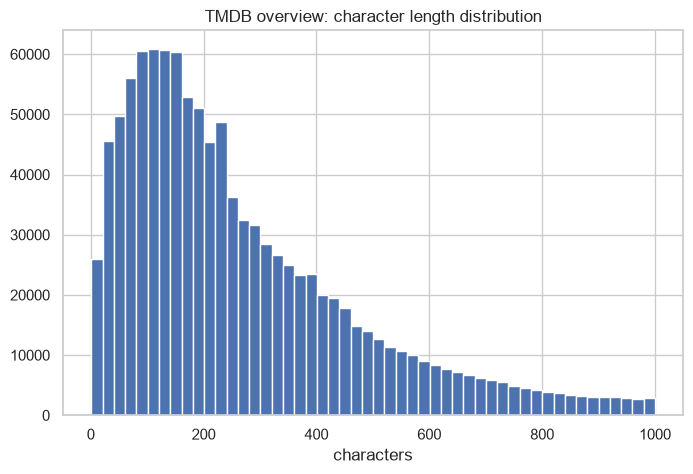

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb_overview_len.hist(bins=50, ax=ax)
ax.set_title("TMDB overview: character length distribution")
ax.set_xlabel("characters")
savefig(fig, "00_tmdb_overview_length_hist.png")
plt.show()

##### Token length (paraphrase-multilingual-mpnet-base-v2 tokenizer, 20000-row sample)

In [52]:
tmdb_overview_token_lengths, tmdb_overview_pct_over_128 = token_length_stats(tmdb["overview"])
print(f"TMDB overview: {tmdb_overview_pct_over_128:.1f}% of sampled rows exceed 128 tokens")
tmdb_overview_token_lengths.describe()

TMDB overview: 12.2% of sampled rows exceed 128 tokens


count    20000.000000
mean        67.128200
std         50.719922
min          2.000000
25%         30.000000
50%         53.000000
75%         92.000000
max        327.000000
Name: overview, dtype: float64

##### Non-English sample flagging (5000-row sample)

In [53]:
tmdb_overview_non_english, tmdb_overview_pct_non_english, tmdb_overview_pct_too_short, tmdb_overview_pct_uncertain = flag_non_english(tmdb["overview"])
tmdb_overview_non_english.head(20)

5000 sampled rows: 0.2% non-English, 6.4% too short to classify, 93.4% uncertain


82800      I en lille provinsby residerer bankdirektør L....
1056376           Rui Veloso - Ao Vivo no Pavilhao Atlantico
48264      Nous sommes dans un coin de France reculé... t...
1449370           Film version of Dagmar Joensen-Næs' novel.
309870     Lizzy Siddal 1829-1862, Pre Rapahelites model,...
153726     Film o przyjaźni dwóch dziewcząt, które poznaj...
1086813          Gerijpt duo vertoont sensationeel herenleed
101804     Η ζωή στην Πεζούλα και τη Βρυσούλα κυλούσε αρμ...
1040112    Film starring Simi Garewal, Vikram and Baby Geeta
1194740             A film by Cooperativa di Monte Olimpino.
707246           16mm student film by Lyndon J. Barrois, Sr.
358755          Full $uicideboy$ Rolling Loud Miami 2022 Set
Name: overview, dtype: str

##### HTML/markup contamination

In [54]:
tmdb_overview_html_pct = html_contamination_pct(tmdb["overview"])
print(f"TMDB overview: {tmdb_overview_html_pct:.2f}% of rows contain HTML/markup")

TMDB overview: 0.01% of rows contain HTML/markup


##### Near-duplicate detection

In [55]:
tmdb_overview_dupes, tmdb_overview_n_dupe_rows = near_duplicate_report(tmdb, "overview", id_col="id")
tmdb_overview_dupes.head(20)

47657 rows share duplicated normalized text across 11367 distinct text groups


,id,imdb_id,overview
326126,441448,<NA>,"""A Brush with Love,"" Directed by Luke Henshaw,..."
326128,441447,<NA>,"""A Brush with Love,"" Directed by Luke Henshaw,..."
81895,1108452,<NA>,"""a colorful poem of the first copy-motion film..."
96959,1109299,<NA>,"""a colorful poem of the first copy-motion film..."
108593,410390,tt2017027,"""A Magic Mirror"" is the least 'sexy' of the ta..."
768605,1447202,<NA>,"""A Magic Mirror"" is the least 'sexy' of the ta..."
768612,1447201,<NA>,"""A Magic Mirror"" is the least 'sexy' of the ta..."
1255001,1120035,<NA>,"""A seat by the window in the train. A view. Wa..."
1255006,1120040,<NA>,"""A seat by the window in the train. A view. Wa..."
1255007,1120042,<NA>,"""A seat by the window in the train. A view. Wa..."


#### `tagline`

##### Nulls & empty strings

In [56]:
tmdb_tagline_nulls, tmdb_tagline_empty = text_field_report(tmdb, "tagline", "TMDB tagline")

TMDB tagline (tagline) — nulls: 1206920, empty strings: 1206920


##### Character length distribution

In [57]:
tmdb_tagline_len = tmdb["tagline"].dropna().astype(str).str.len()
tmdb_tagline_len.describe()

count    194578.000000
mean         45.000385
std          34.264689
min           1.000000
25%          24.000000
50%          36.000000
75%          54.000000
max         256.000000
Name: tagline, dtype: float64

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_tagline_length_hist.png


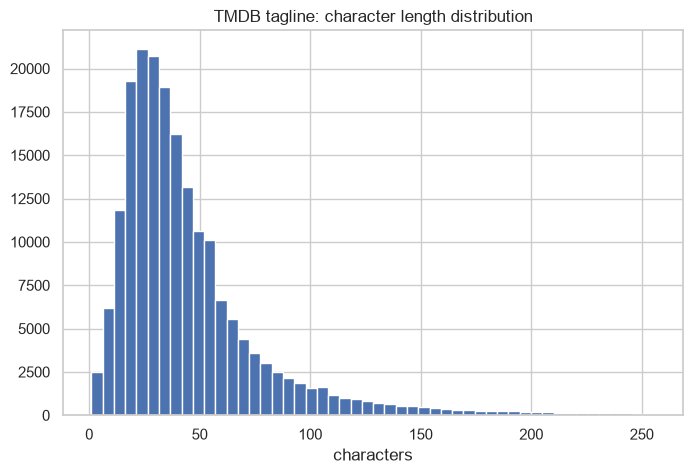

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb_tagline_len.hist(bins=50, ax=ax)
ax.set_title("TMDB tagline: character length distribution")
ax.set_xlabel("characters")
savefig(fig, "00_tmdb_tagline_length_hist.png")
plt.show()

##### Token length (paraphrase-multilingual-mpnet-base-v2 tokenizer, 20000-row sample)

In [59]:
tmdb_tagline_token_lengths, tmdb_tagline_pct_over_128 = token_length_stats(tmdb["tagline"])
print(f"TMDB tagline: {tmdb_tagline_pct_over_128:.1f}% of sampled rows exceed 128 tokens")
tmdb_tagline_token_lengths.describe()

TMDB tagline: 0.0% of sampled rows exceed 128 tokens


count    20000.000000
mean        13.971650
std          8.688965
min          3.000000
25%          8.000000
50%         12.000000
75%         17.000000
max         86.000000
Name: tagline, dtype: float64

##### Non-English sample flagging (5000-row sample)

In [60]:
tmdb_tagline_non_english, tmdb_tagline_pct_non_english, tmdb_tagline_pct_too_short, tmdb_tagline_pct_uncertain = flag_non_english(tmdb["tagline"])
tmdb_tagline_non_english.head(20)

5000 sampled rows: 0.4% non-English, 57.9% too short to classify, 41.7% uncertain


808921             'di mo kailangang baguhin ang iyong anyo.
569406     Bendita Rita da Lua Cheia, Rogai por Mim Nesse...
1107312    Zwei Männer, durch Comedy vereint, durch Unter...
481043     Call Girls in Deira Dubai 00971556872006 Lavis...
1240653    Bawa’t Ala-ala...Ay Mananatiling Buhay sa Guni...
1259551    AKB48 2013 Manatsu no Dome Tour ~Mada mada, Ya...
288410          Taong Mahilig Sa Gusot, Pag-Ibig Ang Lulusot
663777     پیامبر اکرم (ص): «حسین چراغ هدایت و کشتی نجات ...
1324879    "Mais vous avez tout à fait raison, Monsieur l...
1082083    It Up To You How You Handle Yourself [Pandai-p...
1274330          Cuando dios te abandona, nada te protegerá-
84639      Bonsoir, bonsoir! Comment ca va? Voulez vous c...
555945          drink deep, trip, repeat….. until you can’t…
132029         When you best buddy in an already dead buddy.
258337     ¿Con quién te quedarías, con el amor de tu vid...
464613     Gaano ba kalayo ang langit sa lupa at tila ba’...
383952     Poker ist ein

##### HTML/markup contamination

In [61]:
tmdb_tagline_html_pct = html_contamination_pct(tmdb["tagline"])
print(f"TMDB tagline: {tmdb_tagline_html_pct:.2f}% of rows contain HTML/markup")

TMDB tagline: 0.00% of rows contain HTML/markup


##### Near-duplicate detection

In [62]:
tmdb_tagline_dupes, tmdb_tagline_n_dupe_rows = near_duplicate_report(tmdb, "tagline", id_col="id")
tmdb_tagline_dupes.head(20)

14906 rows share duplicated normalized text across 4582 distinct text groups


,id,imdb_id,tagline
333454,1618115,<NA>,"""...when the character faces personal growth, ..."
720246,1618562,<NA>,"""...when the character faces personal growth, ..."
729704,1610463,<NA>,"""A new film that will scare your socks off""'"
815347,1435478,<NA>,"""A new film that will scare your socks off""'"
84783,584929,<NA>,"""Accidental Stranger"" is the final entry in Mi..."
913980,584931,<NA>,"""Accidental Stranger"" is the final entry in Mi..."
273902,1433769,tt2059290,"""Beyond reality, beyond fantasy, beyond your w..."
318283,1477156,tt2059290,"""BEYOND REALITY, BEYOND FANTASY, BEYOND YOUR W..."
648874,1558697,<NA>,"""Clean up on aisle 5."""
898866,1706485,tt11620828,"""Clean up on aisle 5."""


#### `title`

##### Nulls & empty strings

In [63]:
tmdb_title_nulls, tmdb_title_empty = text_field_report(tmdb, "title", "TMDB title")

TMDB title (title) — nulls: 14, empty strings: 17


##### Character length distribution

In [64]:
tmdb_title_len = tmdb["title"].dropna().astype(str).str.len()
tmdb_title_len.describe()

count    1.401484e+06
mean     2.030110e+01
std      1.470744e+01
min      1.000000e+00
25%      1.100000e+01
50%      1.700000e+01
75%      2.500000e+01
max      3.240000e+02
Name: title, dtype: float64

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_title_length_hist.png


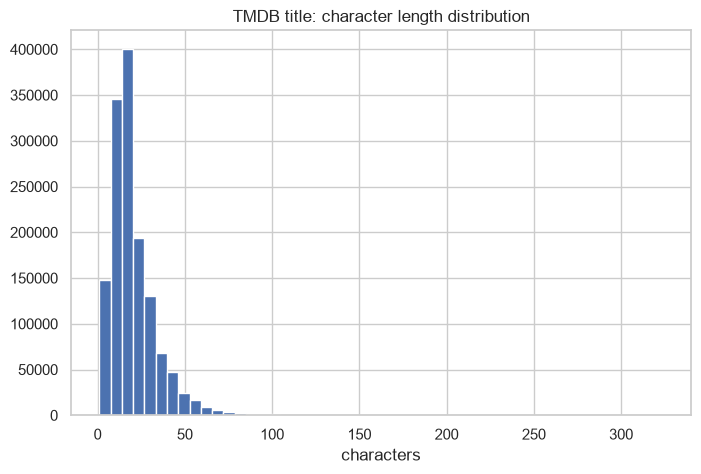

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb_title_len.hist(bins=50, ax=ax)
ax.set_title("TMDB title: character length distribution")
ax.set_xlabel("characters")
savefig(fig, "00_tmdb_title_length_hist.png")
plt.show()

##### Token length (paraphrase-multilingual-mpnet-base-v2 tokenizer, 20000-row sample)

In [66]:
tmdb_title_token_lengths, tmdb_title_pct_over_128 = token_length_stats(tmdb["title"])
print(f"TMDB title: {tmdb_title_pct_over_128:.1f}% of sampled rows exceed 128 tokens")
tmdb_title_token_lengths.describe()

TMDB title: 0.0% of sampled rows exceed 128 tokens


count    20000.000000
mean         8.028400
std          4.815792
min          3.000000
25%          5.000000
50%          7.000000
75%          9.000000
max        109.000000
Name: title, dtype: float64

##### Non-English sample flagging (5000-row sample)

In [67]:
tmdb_title_non_english, tmdb_title_pct_non_english, tmdb_title_pct_too_short, tmdb_title_pct_uncertain = flag_non_english(tmdb["title"])
tmdb_title_non_english.head(20)

5000 sampled rows: 2.2% non-English, 91.7% too short to classify, 6.2% uncertain


321219     La collection Cousteau N°28-2 - La machine à r...
775788     MIMK-117 フラチ ランキング1位三冠制覇！好きになってはいけない向かい部屋の住人と都...
656021             Magyar népmesék: Kecskekatonaság (K.u.K.)
1395942      Die kriegerischen Abenteuer eines Friedfertigen
692152     Batsuichi jukujo no seiyoku: Misoji wa ushiro ...
1054738      Geschichte des Rittmeisters Schach von Wuthenow
724257          Les joyeux compagnons - Ou la corde sensible
293452     Des Français libres, les combats pour la libér...
310954            Pearl Jam: Gigaton Visual Album Experience
804095     Um Minuto é uma Eternidade para Quem Está Sofr...
822305     kinok anti-montaje / kinok no kinok / kinok = ...
392443            Rammstein - Videos 1995-2012 (2012) Vol. 2
1082793             Z archiwum Tey czyli retroTEYada część 4
719790     強●クスリ漬け　塩対応の元キャバ嬢を拉致！ビンタイラマ折檻でドM覚醒ぶっ飛び寄り眼アヘ堕ち痙...
641910     Vulfpeck - MSG II - Live at Madison Square Gar...
1004067    Transform 20 Extra - Nutrition & Meal Guide Tu...
1207845          Illegal

##### HTML/markup contamination

In [68]:
tmdb_title_html_pct = html_contamination_pct(tmdb["title"])
print(f"TMDB title: {tmdb_title_html_pct:.2f}% of rows contain HTML/markup")

TMDB title: 0.03% of rows contain HTML/markup


##### Near-duplicate detection

In [69]:
tmdb_title_dupes, tmdb_title_n_dupe_rows = near_duplicate_report(tmdb, "title", id_col="id")
tmdb_title_dupes.head(20)

301125 rows share duplicated normalized text across 79938 distinct text groups


,id,imdb_id,title
882947,1504039,<NA>,"""..."""
1360095,766763,<NA>,"""..."""
722544,1624145,<NA>,"""A Good Man"""
746336,1625137,tt39411010,"""A Good Man"""
254394,1229508,<NA>,"""concept"""
254515,1229321,<NA>,"""concept"""
377464,1178778,tt1415016,"""Doctor Who"" The End of Time: Part One"
649605,1560219,tt1415016,"""Doctor Who"" The End of Time: Part One"
377459,1178780,tt1415017,"""Doctor Who"" The End of Time: Part Two"
519932,1223874,tt1415017,"""Doctor Who"" The End of Time: Part Two"


#### `original_title`

##### Nulls & empty strings

In [70]:
tmdb_original_title_nulls, tmdb_original_title_empty = text_field_report(tmdb, "original_title", "TMDB original_title")

TMDB original_title (original_title) — nulls: 14, empty strings: 14


##### Character length distribution

In [71]:
tmdb_original_title_len = tmdb["original_title"].dropna().astype(str).str.len()
tmdb_original_title_len.describe()

count    1.401484e+06
mean     1.931825e+01
std      1.331609e+01
min      1.000000e+00
25%      1.000000e+01
50%      1.600000e+01
75%      2.400000e+01
max      2.540000e+02
Name: original_title, dtype: float64

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\00\00_tmdb_original_title_length_hist.png


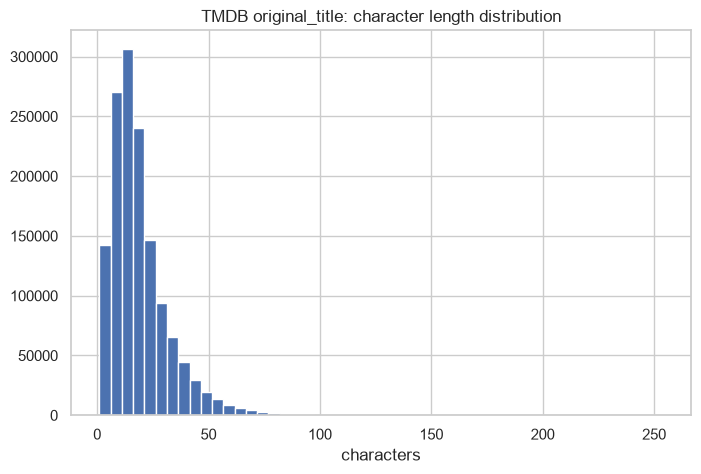

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb_original_title_len.hist(bins=50, ax=ax)
ax.set_title("TMDB original_title: character length distribution")
ax.set_xlabel("characters")
savefig(fig, "00_tmdb_original_title_length_hist.png")
plt.show()

##### Token length (paraphrase-multilingual-mpnet-base-v2 tokenizer, 20000-row sample)

In [73]:
tmdb_original_title_token_lengths, tmdb_original_title_pct_over_128 = token_length_stats(tmdb["original_title"])
print(f"TMDB original_title: {tmdb_original_title_pct_over_128:.1f}% of sampled rows exceed 128 tokens")
tmdb_original_title_token_lengths.describe()

TMDB original_title: 0.0% of sampled rows exceed 128 tokens


count    20000.000000
mean         8.151650
std          4.907826
min          3.000000
25%          5.000000
50%          7.000000
75%          9.000000
max         92.000000
Name: original_title, dtype: float64

##### Non-English sample flagging (5000-row sample)

In [74]:
tmdb_original_title_non_english, tmdb_original_title_pct_non_english, tmdb_original_title_pct_too_short, tmdb_original_title_pct_uncertain = flag_non_english(tmdb["original_title"])
tmdb_original_title_non_english.head(20)

5000 sampled rows: 2.2% non-English, 91.6% too short to classify, 6.1% uncertain


1046346         శ్రీ కనకమలక్ష్మి రికార్డింగ్ డ్యాన్స్ ట్రూప్
963754      Gusttavo Lima – Buteco do Gusttavo Lima – Vol. 2
820085     も、もしも若宮穂乃が、西新宿で働く年収８００万のキャリアウーマンなのに、無職の僕に一方的に想...
501915              somos / tudo tão tanto / tudo meio junto
618000     Stalingrad, au coeur de la bataille aux deux m...
380977     Тайны дворцовых переворотов 2. Завещание Импер...
1212815          Ulsted: Nordjyllands dårligste fodboldhold?
1103322     Augsburger Puppenkiste - Eine kleine Zauberflöte
1008911           La fantaisie douce de Jean-Pierre Marielle
742620        Mata Influencer: Tidinha, a Última Transmissão
1198893        もったいないからザーメン全部舐めとってごっくんしちゃう！節約ママのティッシュ性活 森沢かな
1311253    Frau.Macht.Kirche - Eine Institution gerät ins...
473740     KTKL-084 アナル処女をファンに販売した崖っぷち貧困アイドルいのりちゃん サブスク会員...
438412     Heavysaurus - Kaugummi ist mega Tour 2023 - Le...
1123387         Anna Dai Capelli Rossi - Anna Trova Un'Amica
1437110        Proprio Così. Storie di Ordinaria Occupazione
523395           Мы поже

##### HTML/markup contamination

In [75]:
tmdb_original_title_html_pct = html_contamination_pct(tmdb["original_title"])
print(f"TMDB original_title: {tmdb_original_title_html_pct:.2f}% of rows contain HTML/markup")

TMDB original_title: 0.03% of rows contain HTML/markup


##### Near-duplicate detection

In [76]:
tmdb_original_title_dupes, tmdb_original_title_n_dupe_rows = near_duplicate_report(tmdb, "original_title", id_col="id")
tmdb_original_title_dupes.head(20)

260322 rows share duplicated normalized text across 76721 distinct text groups


,id,imdb_id,original_title
882947,1504039,<NA>,"""..."""
1360095,766763,<NA>,"""..."""
722544,1624145,<NA>,"""A Good Man"""
746336,1625137,tt39411010,"""A Good Man"""
254394,1229508,<NA>,"""concept"""
254515,1229321,<NA>,"""concept"""
377464,1178778,tt1415016,"""Doctor Who"" The End of Time: Part One"
649605,1560219,tt1415016,"""Doctor Who"" The End of Time: Part One"
377459,1178780,tt1415017,"""Doctor Who"" The End of Time: Part Two"
519932,1223874,tt1415017,"""Doctor Who"" The End of Time: Part Two"


## 5. List-valued features (Section 2d)

Covers TMDB `genres`, `keywords`, `production_companies`,
`production_countries`, and `spoken_languages`. TMDB stores these as
comma-separated plain strings rather than JSON, so `parse_list_field()`
(defined in Setup) tries `json.loads` / `ast.literal_eval` first and
falls back to a comma split otherwise.

### Parsing verification

In [77]:
for col, df_ in [
    ("genres", tmdb),
    ("keywords", tmdb),
    ("production_companies", tmdb),
    ("production_countries", tmdb),
    ("spoken_languages", tmdb),
]:
    sample_val = df_[col].dropna().iloc[0]
    print(f"--- {col} ---")
    print("raw:", sample_val)
    print("parsed:", parse_list_field(sample_val))
    print()

--- genres ---
raw: Action, Science Fiction, Adventure
parsed: ['Action', 'Science Fiction', 'Adventure']

--- keywords ---
raw: rescue, mission, dream, airplane, paris, france, virtual reality, kidnapping, philosophy, spy, allegory, manipulation, car crash, heist, memory, architecture, los angeles, california, dream world, subconscious
parsed: ['rescue', 'mission', 'dream', 'airplane', 'paris', 'france', 'virtual reality', 'kidnapping', 'philosophy', 'spy', 'allegory', 'manipulation', 'car crash', 'heist', 'memory', 'architecture', 'los angeles', 'california', 'dream world', 'subconscious']

--- production_companies ---
raw: Legendary Pictures, Syncopy, Warner Bros. Pictures
parsed: ['Legendary Pictures', 'Syncopy', 'Warner Bros. Pictures']

--- production_countries ---
raw: United Kingdom, United States of America
parsed: ['United Kingdom', 'United States of America']

--- spoken_languages ---
raw: English, French, Japanese, Swahili
parsed: ['English', 'French', 'Japanese', 'Swahili'

In [78]:
tmdb["genres_list"] = tmdb["genres"].apply(parse_list_field)
tmdb["keywords_list"] = tmdb["keywords"].apply(parse_list_field)
tmdb["production_companies_list"] = tmdb["production_companies"].apply(parse_list_field)
tmdb["production_countries_list"] = tmdb["production_countries"].apply(parse_list_field)
tmdb["spoken_languages_list"] = tmdb["spoken_languages"].apply(parse_list_field)

### TMDB `genres`

#### Vocabulary & frequency

In [79]:
tmdb_genres_summary = list_field_summary(tmdb, "genres_list")
tmdb_genres_vocab = tmdb_genres_summary["vocab_size"]
print(f"Vocabulary size: {tmdb_genres_vocab}")
print(f"Long-tail items (<10 occurrences): {tmdb_genres_summary['long_tail_items']}")
tmdb_genres_summary["freq"].head(20)

Vocabulary size: 19
Long-tail items (<10 occurrences): 0


genres_list
Drama              250716
Documentary        195681
Comedy             153662
Animation           65576
Horror              60558
Romance             57800
Music               56361
Thriller            50603
Action              47223
Crime               36356
Family              30201
Fantasy             26126
Adventure           25643
TV Movie            25578
Science Fiction     23959
Mystery             22940
History             18276
War                 11416
Western              9313
Name: count, dtype: int64

#### List length & emptiness

In [80]:
print(tmdb_genres_summary["length_describe"])
print(f"% rows with empty list: {tmdb_genres_summary['pct_empty_lists']:.2f}%")

count    1.401498e+06
mean     8.333854e-01
std      9.593919e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.900000e+01
Name: genres_list, dtype: float64
% rows with empty list: 44.97%


#### Multi-hot feasibility

In [81]:
multihot_feasibility(tmdb_genres_vocab, len(tmdb))

Multi-hot matrix estimate: 19 vocab x 1401498 rows = 26,628,462 bytes (~26.6 MB)
Multi-hot encoding is feasible at this vocabulary size.


#### Co-occurrence of top 20 genres

In [82]:
top_item_cooccurrence(tmdb["genres_list"], top_n=20)

,Drama,Documentary,Comedy,Animation,Horror,Romance,Music,Thriller,Action,Crime,Family,Fantasy,Adventure,TV Movie,Science Fiction,Mystery,History,War,Western
Drama,250671,4520,31463,3759,7656,30157,5799,17980,13955,16328,8524,6402,5861,10829,5091,8185,8397,6286,1479
Documentary,4520,195643,3459,2448,1032,362,10530,276,690,1235,1263,414,1495,3969,498,527,6565,2168,109
Comedy,31463,3459,153645,9752,9350,18480,6861,4062,8639,5974,8568,5685,5868,5025,4430,2685,877,694,1183
Animation,3759,2448,9752,65568,2217,1083,2150,525,3208,497,7980,4916,4345,779,3304,818,614,482,207
Horror,7656,1032,9350,2217,60552,1200,712,12341,2849,1873,365,3841,1055,976,4206,5717,263,188,226
Romance,30157,362,18480,1083,1200,57796,2966,2188,2655,1823,1773,2194,1681,2914,1062,1358,1035,882,553
Music,5799,10530,6861,2150,712,2966,56343,269,511,365,1827,1244,614,1168,443,286,715,169,272
Thriller,17980,276,4062,525,12341,2188,269,50599,8055,9480,297,1480,1660,2876,3195,7909,470,471,248
Action,13955,690,8639,3208,2849,2655,511,8055,47219,7425,1219,3348,8247,1232,5329,1495,1205,1557,1274
Crime,16328,1235,5974,497,1873,1823,365,9480,7425,36354,363,398,1337,2200,506,4680,431,174,254


### TMDB `keywords`

#### Vocabulary & frequency

In [83]:
tmdb_keywords_summary = list_field_summary(tmdb, "keywords_list")
tmdb_keywords_vocab = tmdb_keywords_summary["vocab_size"]
print(f"Vocabulary size: {tmdb_keywords_vocab}")
print(f"Long-tail items (<10 occurrences): {tmdb_keywords_summary['long_tail_items']}")
tmdb_keywords_summary["freq"].head(20)

Vocabulary size: 68696
Long-tail items (<10 occurrences): 56109


keywords_list
short film                29269
gay pornography           16573
woman director            15768
anal sex                   6102
based on novel or book     6038
concert                    5268
compilation                5258
lgbt                       5075
murder                     4868
biography                  4006
big tits                   3903
silent film                3814
softcore                   3673
sports                     3648
stand-up comedy            3636
musical                    3563
gay theme                  3491
christmas                  2962
lesbian sex                2821
love                       2804
Name: count, dtype: int64

#### List length & emptiness

In [84]:
# DECISION POINT: ~75% of rows have an empty keywords list. "Empty" here
# doesn't yet distinguish genuinely-missing (NaN, never tagged) from
# explicitly-empty (parsed to [] from an empty string) — same disguised-
# missingness risk seen elsewhere in this dataset.
# TODO: check whether emptiness correlates with release_date/popularity
# (structured vs. random), and decide how encoding should represent "no
# keywords" before treating this field as a primary feature.
print(tmdb_keywords_summary["length_describe"])
print(f"% rows with empty list: {tmdb_keywords_summary['pct_empty_lists']:.2f}%")

count    1.401498e+06
mean     7.830942e-01
std      2.146067e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.190000e+02
Name: keywords_list, dtype: float64
% rows with empty list: 75.51%


#### Multi-hot feasibility

In [85]:
multihot_feasibility(tmdb_keywords_vocab, len(tmdb))

Multi-hot matrix estimate: 68696 vocab x 1401498 rows = 96,277,306,608 bytes (~96277.3 MB)


#### Co-occurrence of top 20 keywords

In [86]:
top_item_cooccurrence(tmdb["keywords_list"], top_n=20)

,short film,gay pornography,woman director,anal sex,based on novel or book,concert,compilation,lgbt,murder,biography,big tits,silent film,softcore,sports,stand-up comedy,musical,gay theme,christmas,lesbian sex,love
short film,29269,12,1104,2,81,9,11,1306,84,110,0,793,3,111,8,122,725,156,13,154
gay pornography,12,16573,4,1303,2,0,2042,23,0,0,0,0,2,7,0,0,56,12,0,0
woman director,1104,4,15768,74,215,27,4,278,100,173,8,112,9,73,33,69,98,87,66,110
anal sex,2,1303,74,6102,0,0,303,1,0,0,197,0,1,9,0,1,14,9,117,1
based on novel or book,81,2,215,0,6038,3,0,73,276,117,0,98,10,37,0,72,66,86,4,133
concert,9,0,27,0,3,5268,4,5,5,15,0,0,0,0,20,98,1,23,0,5
compilation,11,2042,4,303,0,4,5258,3,1,0,317,3,1,1,3,4,6,6,130,1
lgbt,1306,23,278,1,73,5,3,5075,40,73,0,10,7,25,16,44,1721,28,16,98
murder,84,0,100,0,276,5,1,40,4868,23,1,19,15,7,0,10,43,46,13,75
biography,110,0,173,0,117,15,0,73,23,4006,0,13,0,183,5,46,37,3,0,15


### TMDB `production_companies`

#### Vocabulary & frequency

In [87]:
tmdb_production_companies_summary = list_field_summary(tmdb, "production_companies_list")
tmdb_production_companies_vocab = tmdb_production_companies_summary["vocab_size"]
print(f"Vocabulary size: {tmdb_production_companies_vocab}")
print(f"Long-tail items (<10 occurrences): {tmdb_production_companies_summary['long_tail_items']}")
tmdb_production_companies_summary["freq"].head(20)

Vocabulary size: 182102
Long-tail items (<10 occurrences): 170637


production_companies_list
BBC                      3521
Evil Angel               3238
Warner Bros. Pictures    3181
Columbia Pictures        2932
ARTE                     2930
ONF | NFB                2889
Metro-Goldwyn-Mayer      2860
Universal Pictures       2582
Paramount                2552
ZDF                      2422
Toei Company             2328
Nikkatsu Corporation     1973
20th Century Fox         1747
Private                  1678
ARD                      1573
Mosfilm                  1566
Canal+                   1557
TOHO                     1525
Shochiku                 1487
New Sensations           1464
Name: count, dtype: int64

#### List length & emptiness

In [88]:
print(tmdb_production_companies_summary["length_describe"])
print(f"% rows with empty list: {tmdb_production_companies_summary['pct_empty_lists']:.2f}%")

count    1.401498e+06
mean     5.894721e-01
std      9.482770e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.400000e+01
Name: production_companies_list, dtype: float64
% rows with empty list: 58.14%


#### Multi-hot feasibility

In [89]:
multihot_feasibility(tmdb_production_companies_vocab, len(tmdb))

Multi-hot matrix estimate: 182102 vocab x 1401498 rows = 255,215,588,796 bytes (~255215.6 MB)


#### Co-occurrence of top 20 production companies

In [90]:
top_item_cooccurrence(tmdb["production_companies_list"], top_n=20)

,BBC,Evil Angel,Warner Bros. Pictures,Columbia Pictures,ARTE,ONF | NFB,Metro-Goldwyn-Mayer,Universal Pictures,Paramount,ZDF,Toei Company,Nikkatsu Corporation,20th Century Fox,Private,ARD,Mosfilm,Canal+,TOHO,Shochiku,New Sensations
BBC,3519,0,1,1,26,2,1,3,4,15,0,0,1,0,0,0,3,2,0,0
Evil Angel,0,3238,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Warner Bros. Pictures,1,0,3180,6,0,0,9,7,7,0,1,1,4,0,2,0,18,1,0,0
Columbia Pictures,1,0,6,2932,0,0,18,8,4,0,0,0,4,0,0,1,1,1,0,0
ARTE,26,0,0,0,2898,7,0,0,0,414,0,0,0,0,43,0,24,0,0,0
ONF | NFB,2,0,0,0,7,2888,0,0,0,0,0,0,1,0,0,0,2,0,0,0
Metro-Goldwyn-Mayer,1,0,9,18,0,0,2860,7,7,0,0,0,3,0,0,0,2,0,0,0
Universal Pictures,3,0,7,8,0,0,7,2582,5,0,0,0,3,0,0,0,6,2,0,0
Paramount,4,0,7,4,0,0,7,5,2552,1,0,0,6,0,0,2,2,2,1,0
ZDF,15,0,0,0,414,0,0,0,1,2422,0,0,0,0,5,0,15,0,0,0


### TMDB `production_countries`

#### Vocabulary & frequency

In [91]:
tmdb_production_countries_summary = list_field_summary(tmdb, "production_countries_list")
tmdb_production_countries_vocab = tmdb_production_countries_summary["vocab_size"]
print(f"Vocabulary size: {tmdb_production_countries_vocab}")
print(f"Long-tail items (<10 occurrences): {tmdb_production_countries_summary['long_tail_items']}")
tmdb_production_countries_summary["freq"].head(20)

Vocabulary size: 250
Long-tail items (<10 occurrences): 26


production_countries_list
United States of America    209131
Japan                        52491
France                       49093
Germany                      47188
United Kingdom               47081
Canada                       26133
India                        21578
Brazil                       20904
Italy                        20396
Spain                        17029
Mexico                       13659
Russia                       11480
Soviet Union                 11351
China                        11283
Argentina                    10260
South Korea                   9572
Sweden                        8968
Czech Republic                8527
Australia                     8072
Netherlands                   7989
Name: count, dtype: int64

#### List length & emptiness

In [92]:
print(tmdb_production_countries_summary["length_describe"])
print(f"% rows with empty list: {tmdb_production_countries_summary['pct_empty_lists']:.2f}%")

count    1.401498e+06
mean     5.539958e-01
std      6.819793e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.510000e+02
Name: production_countries_list, dtype: float64
% rows with empty list: 49.21%


#### Multi-hot feasibility

In [93]:
multihot_feasibility(tmdb_production_countries_vocab, len(tmdb))

Multi-hot matrix estimate: 250 vocab x 1401498 rows = 350,374,500 bytes (~350.4 MB)
Multi-hot encoding is feasible at this vocabulary size.


#### Co-occurrence of top 20 production countries

In [94]:
top_item_cooccurrence(tmdb["production_countries_list"], top_n=20)

,United States of America,Japan,France,Germany,United Kingdom,Canada,India,Brazil,Italy,Spain,Mexico,Russia,Soviet Union,China,Argentina,South Korea,Sweden,Czech Republic,Australia,Netherlands
United States of America,209131,728,1487,1449,3285,3254,317,368,731,509,641,227,20,434,199,227,196,208,479,222
Japan,728,52491,331,145,207,103,25,19,59,41,20,31,17,108,11,153,26,5,51,36
France,1487,331,49093,2073,1125,637,94,240,2477,972,137,183,26,172,202,74,198,156,95,298
Germany,1449,145,2073,47188,1001,310,82,121,992,411,103,212,34,79,127,33,307,254,79,305
United Kingdom,3285,207,1125,1001,47081,571,201,97,478,342,74,110,12,114,62,34,160,131,263,237
Canada,3254,103,637,310,571,26133,67,51,115,70,80,28,8,85,39,29,42,87,85,42
India,317,25,94,82,201,67,21578,24,37,24,15,17,10,39,13,22,13,12,25,15
Brazil,368,19,240,121,97,51,24,20904,94,78,54,17,4,29,197,15,13,64,10,40
Italy,731,59,2477,992,478,115,37,94,20396,979,63,61,32,25,97,10,65,37,30,69
Spain,509,41,972,411,342,70,24,78,979,17029,327,31,5,37,395,11,42,30,26,71


### TMDB `spoken_languages`

#### Vocabulary & frequency

In [95]:
tmdb_spoken_languages_summary = list_field_summary(tmdb, "spoken_languages_list")
tmdb_spoken_languages_vocab = tmdb_spoken_languages_summary["vocab_size"]
print(f"Vocabulary size: {tmdb_spoken_languages_vocab}")
print(f"Long-tail items (<10 occurrences): {tmdb_spoken_languages_summary['long_tail_items']}")
tmdb_spoken_languages_summary["freq"].head(20)

Vocabulary size: 185
Long-tail items (<10 occurrences): 30


spoken_languages_list
English        299441
French          54893
Japanese        53300
Spanish         51909
German          42840
No Language     35511
Portuguese      25848
Russian         23236
Italian         22199
Mandarin        20400
Czech           12157
Korean          11586
Arabic          10678
Hindi            8600
Swedish          8117
Dutch            7525
Tagalog          7276
Turkish          6977
Cantonese        6162
Polish           6127
Name: count, dtype: int64

#### List length & emptiness

In [96]:
print(tmdb_spoken_languages_summary["length_describe"])
print(f"% rows with empty list: {tmdb_spoken_languages_summary['pct_empty_lists']:.2f}%")

count    1.401498e+06
mean     5.817939e-01
std      6.341924e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+01
Name: spoken_languages_list, dtype: float64
% rows with empty list: 47.56%


#### Multi-hot feasibility

In [97]:
multihot_feasibility(tmdb_spoken_languages_vocab, len(tmdb))

Multi-hot matrix estimate: 185 vocab x 1401498 rows = 259,277,130 bytes (~259.3 MB)
Multi-hot encoding is feasible at this vocabulary size.


#### Co-occurrence of top 20 spoken languages

In [98]:
top_item_cooccurrence(tmdb["spoken_languages_list"], top_n=20)

,English,French,Japanese,Spanish,German,No Language,Portuguese,Russian,Italian,Mandarin,Czech,Korean,Arabic,Hindi,Swedish,Dutch,Tagalog,Turkish,Cantonese,Polish
English,299441,9003,2734,6876,6661,303,1926,2230,3554,2032,646,902,1968,1497,1079,1009,1600,447,805,728
French,9003,54893,451,1699,2718,54,620,687,1526,332,111,111,1428,70,223,443,25,146,79,218
Japanese,2734,451,53300,264,272,108,95,139,152,460,10,387,60,29,27,31,60,17,175,22
Spanish,6876,1699,264,51909,982,58,743,310,769,208,64,97,363,54,133,118,50,47,45,89
German,6661,2718,272,982,42840,50,283,818,1167,193,255,84,315,54,240,256,22,279,52,413
No Language,303,54,108,58,50,35511,43,27,60,11,8,61,8,5,9,3,0,0,1,7
Portuguese,1926,620,95,743,283,43,25848,79,229,88,56,28,69,22,31,45,6,18,20,30
Russian,2230,687,139,310,818,27,79,23236,262,130,101,54,114,41,106,66,9,49,23,238
Italian,3554,1526,152,769,1167,60,229,262,22199,127,39,28,176,20,89,93,16,64,32,106
Mandarin,2032,332,460,208,193,11,88,130,127,20400,9,201,60,44,25,46,44,24,1154,28


## Log summary

In [99]:
findings = {
    "TMDB rows (raw -> released, zero-coded)": f"{tmdb_shape_raw[0]} -> {tmdb.shape[0]}",
    "TMDB memory footprint (deep)": f"{tmdb_mem_mb:,.1f} MB",
    "TMDB most predictive numeric features (|r| with vote_average)": tmdb_target_corr.head(3).round(3).to_dict(),
    "Entity-embedding dimension table (see notebook Section 3)": embedding_dim_summary.set_index(["dataset", "column"])["suggested_embedding_dim"].to_dict(),
    "TMDB overview: % > 128 tokens (sampled)": f"{tmdb_overview_pct_over_128:.1f}%",
    "TMDB overview: non-English / too short / uncertain (sampled)": (
        f"{tmdb_overview_pct_non_english:.1f}% / {tmdb_overview_pct_too_short:.1f}% / "
        f"{tmdb_overview_pct_uncertain:.1f}%"
    ),
    "TMDB overview: % HTML-contaminated": f"{tmdb_overview_html_pct:.2f}%",
    "TMDB genres vocabulary size": tmdb_genres_vocab,
    "TMDB keywords vocabulary size": tmdb_keywords_vocab,
    "Multi-hot vs pooled-embedding recommendation": (
        "genres: multi-hot feasible; keywords: use pooled "
        "SBERT-of-item-names if vocab_size > 5000 (see Section 5 warnings above)"
    ),
}

log_findings(
    title="00 Characterization: TMDB -- summary",
    findings=findings,
    figures=[
        "reports/figures/00/00_tmdb_missingness_matrix.png",
        "reports/figures/00/00_tmdb_vote_average_hist.png",
        "reports/figures/00/00_tmdb_histograms.png",
        "reports/figures/00/00_tmdb_boxplots.png",
        "reports/figures/00/00_tmdb_correlation_heatmap.png",
        "reports/figures/00/00_tmdb_original_language_long_tail.png",
        "reports/figures/00/00_tmdb_overview_length_hist.png",
        "reports/figures/00/00_tmdb_tagline_length_hist.png",
        "reports/figures/00/00_tmdb_title_length_hist.png",
        "reports/figures/00/00_tmdb_original_title_length_hist.png",
    ],
)
print("Logged summary to reports/eda_log.md")

Logged summary to reports/eda_log.md
